# How should the variables in CovDB Pull be treated as hierarchical layers?

In [204]:
import os
import pandas as pd
import numpy as np

from scipy.stats import ttest_ind, f_oneway

import matplotlib.pyplot as plt
import seaborn as sns

### Read in data

In [52]:
vp_dir = '../data/CoVDB/vp-studies'
cp_dir = '../data/CoVDB/cp-studies'
vp_csvs = [f for f in os.listdir(vp_dir) if f.endswith('.csv')]
cp_csvs = [f for f in os.listdir(cp_dir) if f.endswith('.csv')]

vp = pd.DataFrame()
for f in vp_csvs:
    temp = pd.read_csv(vp_dir+'/'+f)
    vp = pd.concat([vp, temp])

cp = pd.DataFrame()
for f in cp_csvs:
    temp = pd.read_csv(cp_dir+'/'+f)
    cp = pd.concat([cp, temp])
    
# Create a super-df for all plasma types
vp['Plasma'] = 'Vaccine'; vp['Infection (CP)'] = ''
cp['Plasma'] = 'Convalescent'; cp['Pre-vaccine Infection'] = ''; cp['Vaccine'] = ''; cp['# Shots'] = 0
plasma = pd.concat([vp, cp])

# Clean data
plasma = plasma[plasma['Fold Reduction: Cmp']=='=']
plasma = plasma[plasma['# Results']==1]
plasma = plasma[plasma['Control']=='Wild Type (B.1)']
plasma = plasma[plasma['Host']=='Human']

# Drop unnecessary columns
plasma_lite = plasma.drop(columns=['Reference', 'Reference: DOI', 'Section', 'Host', 
                                   'Control', 'Control: NT50 Cmp', 'Control: NT50 GeoMean', 'Control: NT50 GSD', 
                                   'Fold Reduction: Cmp', 'Potency: NT50 Cmp', 'Potency: NT50 GeoMean', 'Potency: NT50 GSD',
                                   'Variant', 'Variant: Pos'
                                   ]
                    ).sort_values(by='Fold Reduction: Median'
                    ).reset_index(drop=True
                    ).reset_index(
                    ).rename(columns={'index':'ID'})

In [100]:
plasma_lite

,ID,Assay,Pre-vaccine Infection,Vaccine,# Shots,Months,Variant: Mutations,# Results,Fold Reduction: Median,Plasma,Infection (CP),color
0,0,Virus isolate,,,0,≥6m,Δ69 + G72R + Δ144 + N501Y + A570D + P681H + T7...,1,0.1,Convalescent,Wild Type,"(0.6196078431372549, 0.00392156862745098, 0.25..."
1,1,Virus isolate,,,0,≥6m,Δ69 + G72R + Δ144 + N501Y + A570D + P681H + T7...,1,0.1,Convalescent,Wild Type,"(0.6196078431372549, 0.00392156862745098, 0.25..."
2,2,Virus isolate,,,0,2-6m,T19R + G142D + Δ156-157 + R158G + L452R + T478...,1,0.1,Convalescent,Delta,"(0.6196078431372549, 0.00392156862745098, 0.25..."
3,3,Virus isolate,,,0,≥6m,L18F + T20N + P26S + D138Y + R190S + K417T + E...,1,0.1,Convalescent,Wild Type,"(0.6196078431372549, 0.00392156862745098, 0.25..."
4,4,Pseudovirus (lentivirus),,,0,1m,Δ69-70 + Y453F,1,0.2,Convalescent,Wild Type,"(0.6196078431372549, 0.00392156862745098, 0.25..."
...,...,...,...,...,...,...,...,...,...,...,...,...
2909,2909,Virus isolate,,,0,≥6m,A67V + Δ69-70 + T95I + G142D + Δ143-145 + N211...,1,126.6,Convalescent,Wild Type,"(0.3686274509803922, 0.30980392156862746, 0.63..."
2910,2910,Virus isolate,,,0,≥6m,A67V + Δ69-70 + T95I + G142D + Δ143-145 + N211...,1,157.6,Convalescent,Wild Type,"(0.3686274509803922, 0.30980392156862746, 0.63..."
2911,2911,Virus isolate,,,0,≥6m,A67V + Δ69-70 + T95I + G142D + Δ143-145 + N211...,1,161.6,Convalescent,Wild Type,"(0.3686274509803922, 0.30980392156862746, 0.63..."
2912,2912,Virus isolate,,,0,≥6m,A67V + Δ69-70 + T95I + G142D + Δ143-145 + N211...,1,200.2,Convalescent,Wild Type,"(0.3686274509803922, 0.30980392156862746, 0.63..."


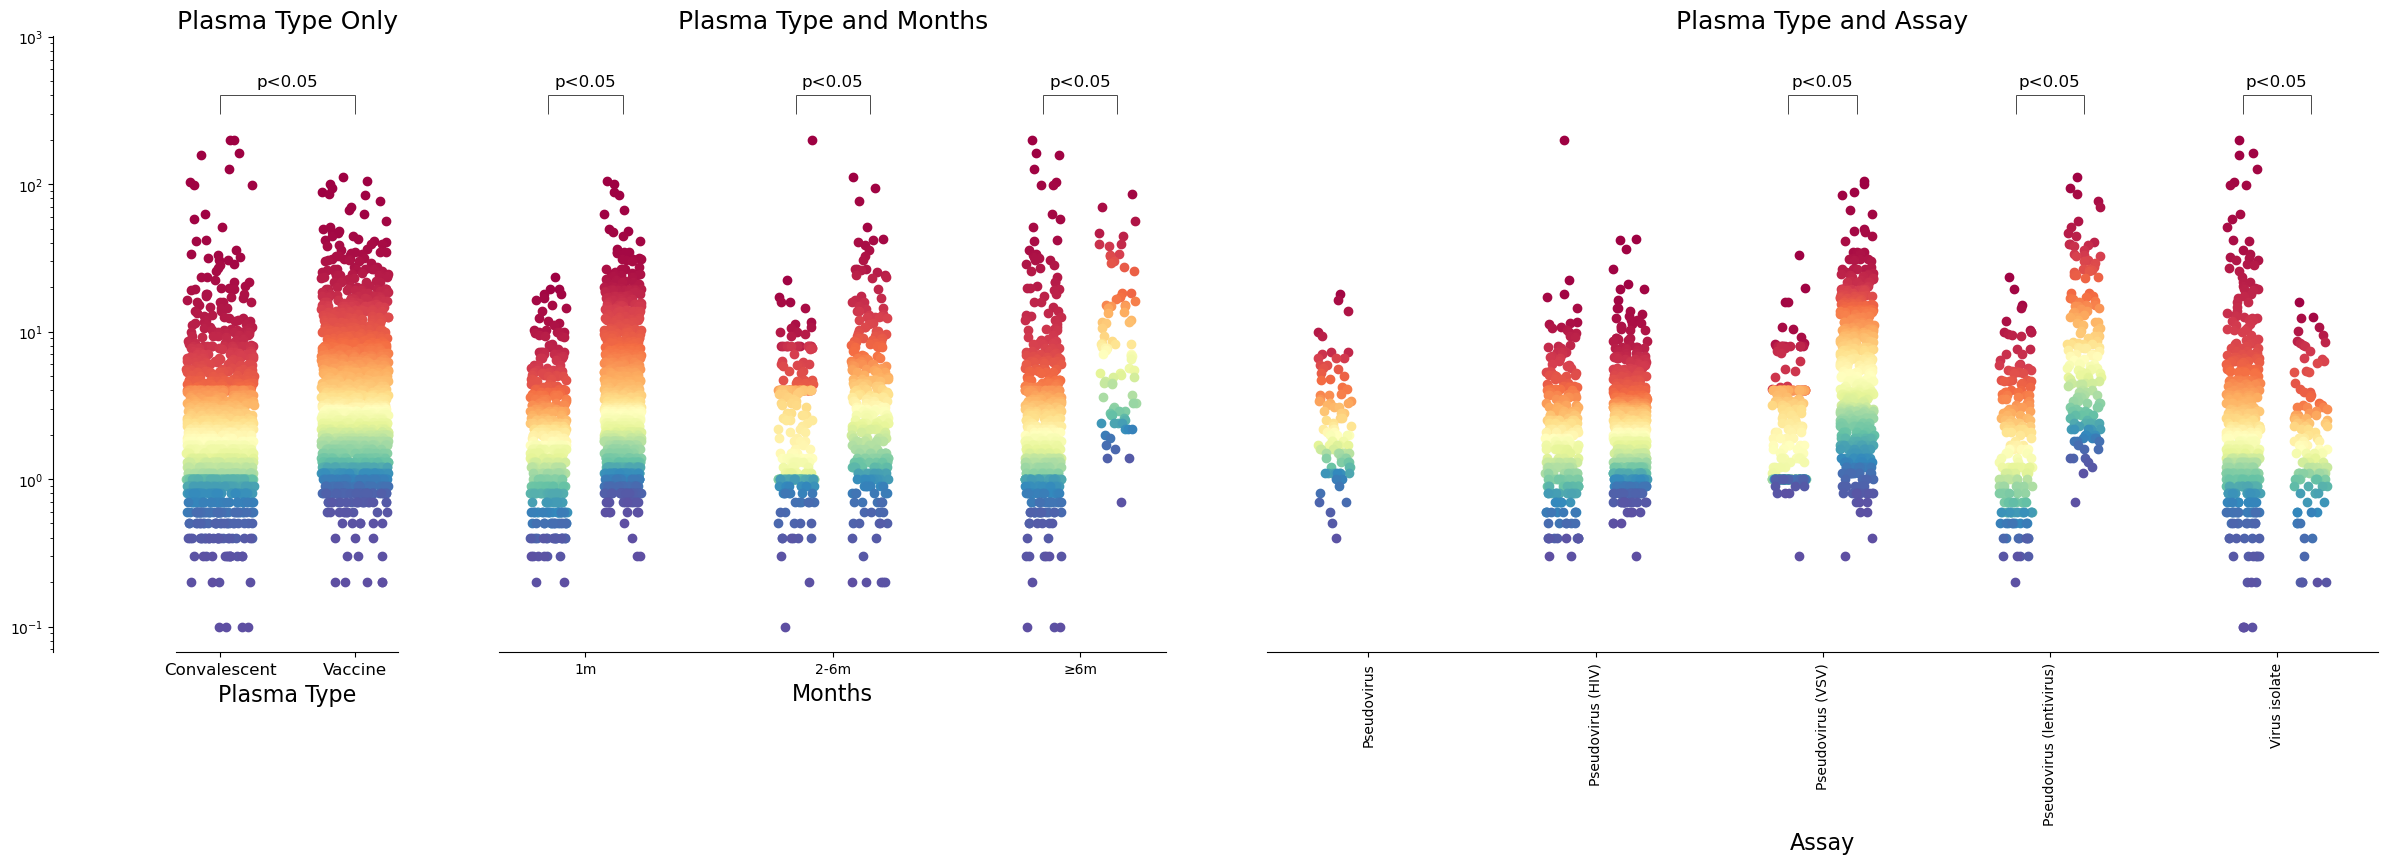

In [200]:
fig, axes = plt.subplots(1, 4, figsize=(30, 8), gridspec_kw={'width_ratios': [0.1, 1, 3, 5]})

jitter_width = 0.15
space = 0.3
palette='Spectral'

miny = plasma_lite['Fold Reduction: Median'].min()
maxy = plasma_lite['Fold Reduction: Median'].max()

# First, just show Plasma types
ax = axes[1]
ax.set_title('Plasma Type Only', fontsize=18)
ax.set_xlabel('Plasma Type', fontsize=16)
s = []
for x, plasma in enumerate(sorted(plasma_lite['Plasma'].unique())):
    temp = plasma_lite[plasma_lite['Plasma']==plasma].copy()
    temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
    yvals = temp['Fold Reduction: Median']
    xvals = (np.random.random(len(yvals))-0.5) * jitter_width + (x-0.5)*space
    color_map = sns.color_palette(palette, len(temp))
    colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
    for xi,yi,ci in zip (xvals, yvals, colors):
        ax.plot(xi, yi, 'o', color=ci)

    s.append(yvals)
x1, x2 = [-space/2, space/2]
ax.set_xticks([x1, x2])
ax.set_xticklabels(sorted(plasma_lite['Plasma'].unique()), fontsize=12)

stat, p = ttest_ind(s[0], s[1])
if p<0.05:
    ax.vlines([x1, x2], maxy*1.5, maxy*2,
             color='black', linewidth=0.5)
    ax.hlines(maxy*2, x1, x2,
             color='black', linewidth=0.5)
    ax.text((x1+x2)/2, maxy*2.2, 'p<0.05', fontsize=12, ha='center', va='bottom')
    


# Next, break up by Months
ax = axes[2]
ax.set_title('Plasma Type and Months', fontsize=18)
ax.set_xlabel('Months', fontsize=16)
xticklabels = []
for x, month in enumerate(sorted(plasma_lite['Months'].unique())):
    x1, x2 = [x-space/2, x+space/2] 
    s = []
    for j, plasma in enumerate(sorted(plasma_lite['Plasma'].unique())):
        temp = plasma_lite[(plasma_lite['Months']==month) & (plasma_lite['Plasma']==plasma)].copy()
        temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
        if len(temp) > 0:
            yvals = temp['Fold Reduction: Median']
            xvals = (np.random.random(len(yvals))-0.5) * jitter_width + x + (j - 0.5)*space
            color_map = sns.color_palette('Spectral', len(temp))
            colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
            for xi,yi,ci in zip (xvals, yvals, colors):
                ax.plot(xi, yi, 'o', color=ci)
                
            s.append(yvals)
    if len(s)==2:
        stat, p = ttest_ind(s[0], s[1])
        if p<0.05:
            ax.vlines([x1, x2], maxy*1.5, maxy*2,
                      color='black', linewidth=0.5)
            ax.hlines(maxy*2, x1, x2,
                      color='black', linewidth=0.5)
            ax.text((x1+x2)/2, maxy*2.2, 'p<0.05', fontsize=12, ha='center', va='bottom')
    xticklabels.append(month)
        
ax.set_xticks([i for i in range(len(xticklabels))])
ax.set_xticklabels(xticklabels)



# Next, break up by assay
ax = axes[3]
ax.set_title('Plasma Type and Assay', fontsize=18)
ax.set_xlabel('Assay', fontsize=16)
xticklabels = []
for x, assay in enumerate(sorted(plasma_lite['Assay'].unique())):
    x1, x2 = [x-space/2, x+space/2] 
    s = []
    for j, plasma in enumerate(sorted(plasma_lite['Plasma'].unique())):
        temp = plasma_lite[(plasma_lite['Assay']==assay) & (plasma_lite['Plasma']==plasma)].copy()
        temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
        if len(temp) > 0:
            yvals = temp['Fold Reduction: Median']
            xvals = (np.random.random(len(yvals))-0.5) * jitter_width + x + (j - 0.5)*space
            color_map = sns.color_palette('Spectral', len(temp))
            colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
            for xi,yi,ci in zip (xvals, yvals, colors):
                ax.plot(xi, yi, 'o', color=ci)
                
            s.append(yvals)
    if len(s)==2:
        stat, p = ttest_ind(s[0], s[1])
        if p<0.05:
            ax.vlines([x1, x2], maxy*1.5, maxy*2,
                      color='black', linewidth=0.5)
            ax.hlines(maxy*2, x1, x2,
                      color='black', linewidth=0.5)
            ax.text((x1+x2)/2, maxy*2.2, 'p<0.05', fontsize=12, ha='center', va='bottom')
    xticklabels.append(assay)
    
        
ax.set_xticks([i for i in range(len(xticklabels))])
ax.set_xticklabels(xticklabels, rotation=90)    

# Format leftmost (reference) axis:
ax = axes[0]
ax.set_yscale('log')
ax.set_ylim([miny/1.5,
             maxy*5])
ax.spines[['bottom', 'right', 'top']].set_visible(False)
ax.set_xticks([], minor=True)
ax.set_xticks([], minor=False)
# Format plotted axes
for ax in axes[1:]:
    ax.set_yscale('log')
    ax.set_ylim([miny/1.5,
                 maxy*5])
    ax.spines[['left', 'right', 'top']].set_visible(False)
    ax.set_yticks([], minor=True)
    ax.set_yticks([], minor=False)

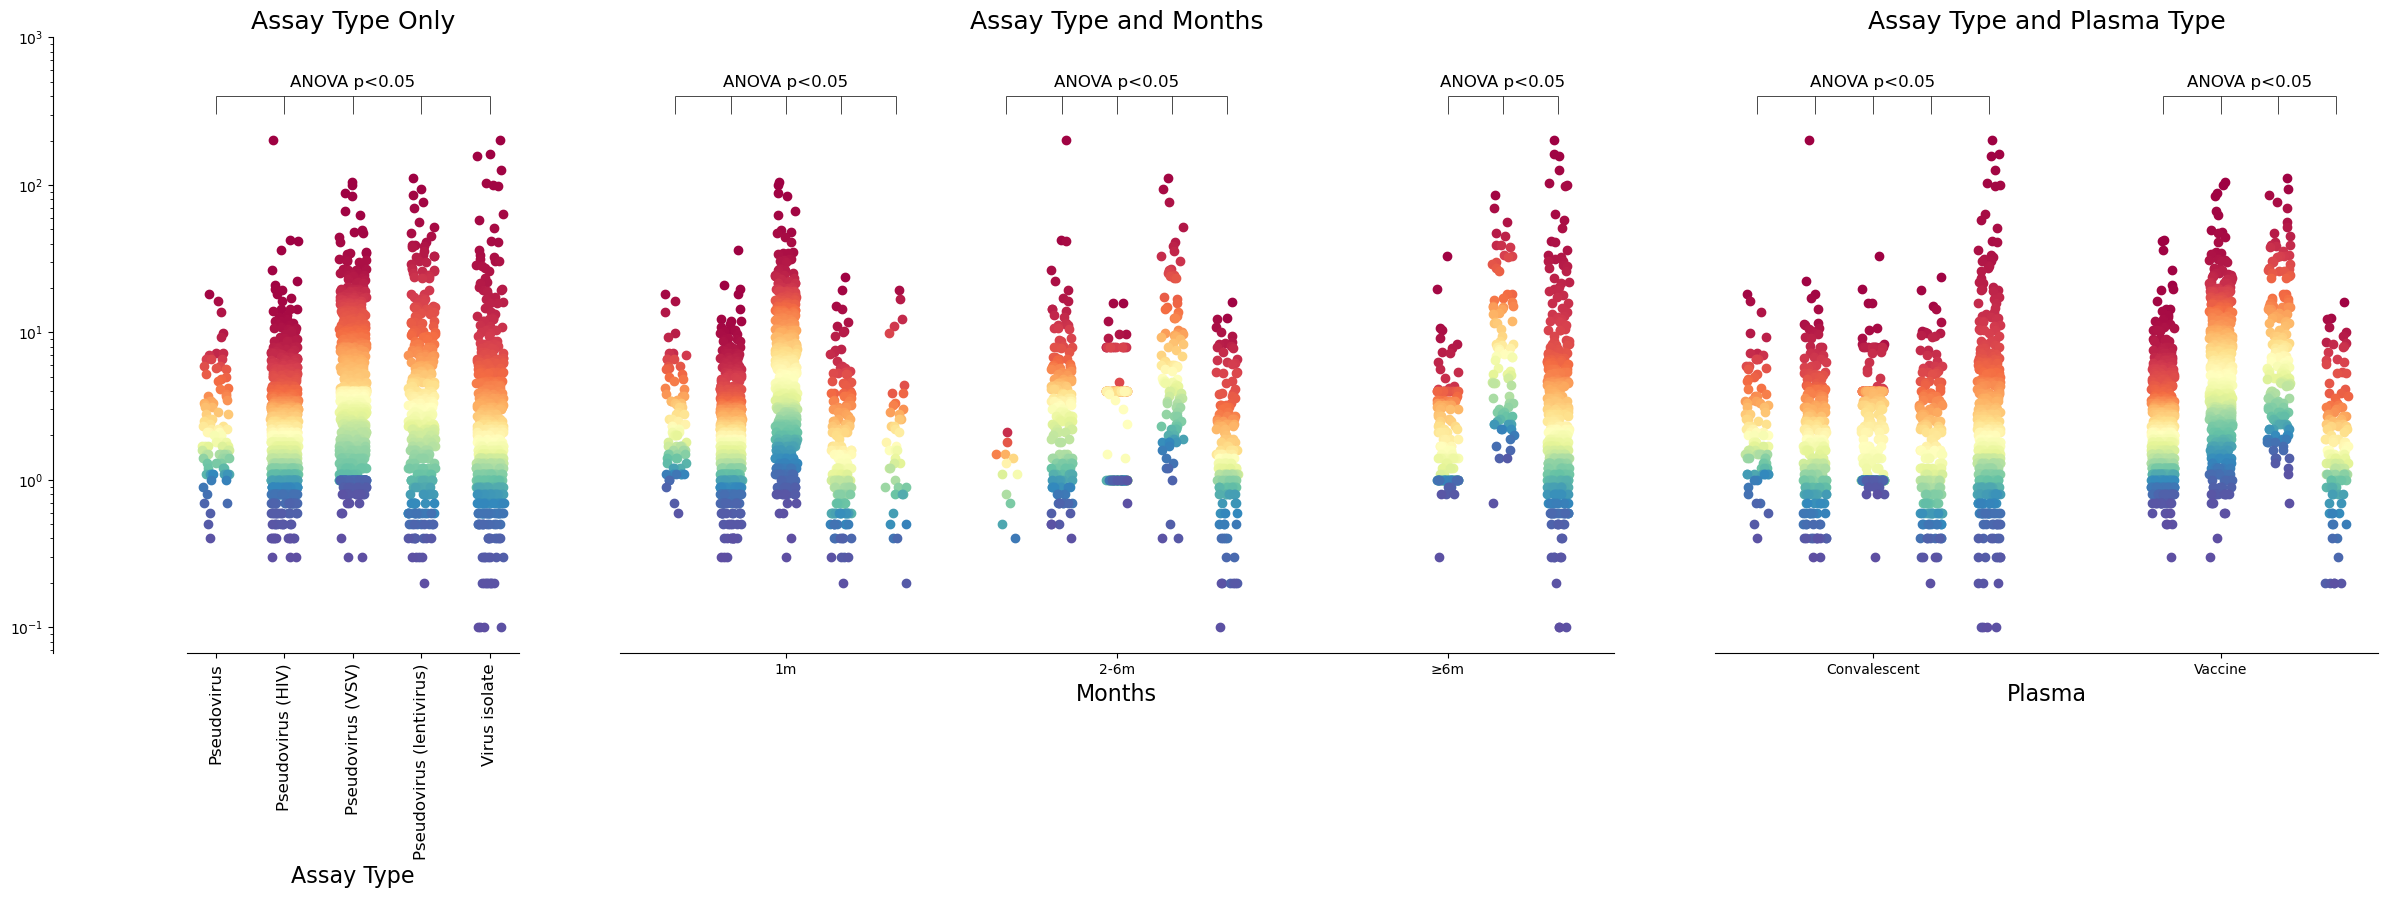

In [238]:
fig, axes = plt.subplots(1, 4, figsize=(30, 8), gridspec_kw={'width_ratios': [0.1, 1, 3, 2]})

jitter_width = 0.4
palette='Spectral'

miny = plasma_lite['Fold Reduction: Median'].min()
maxy = plasma_lite['Fold Reduction: Median'].max()
n_assays = len(plasma_lite['Assay'].unique())

# First, just show Plasma types
ax = axes[1]
ax.set_title('Assay Type Only', fontsize=18)
ax.set_xlabel('Assay Type', fontsize=16)
s = []
xticklabels = []
for x, assay in enumerate(sorted(plasma_lite['Assay'].unique())):
    temp = plasma_lite[plasma_lite['Assay']==assay].copy()
    temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
    yvals = temp['Fold Reduction: Median']
    xvals = (np.random.random(len(yvals))-0.5) * jitter_width + x
    color_map = sns.color_palette(palette, len(temp))
    colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
    for xi,yi,ci in zip (xvals, yvals, colors):
        ax.plot(xi, yi, 'o', color=ci)

    s.append(yvals)
    xticklabels.append(assay)
    
ax.set_xticks([i for i in range(len(xticklabels))])
ax.set_xticklabels(xticklabels, fontsize=12, rotation=90)

stat, p = f_oneway(*s)
if p<0.05:
    ax.vlines([i for i in range(len(xticklabels))], maxy*1.5, maxy*2,
              color='black', linewidth=0.5)
    ax.hlines(maxy*2, 0, len(xticklabels)-1,
              color='black', linewidth=0.5)
    ax.text((len(xticklabels)-1)/2, maxy*2.2, 'ANOVA p<0.05', fontsize=12, ha='center', va='bottom')
    


# Next, break up by Months
ax = axes[2]
ax.set_title('Assay Type and Months', fontsize=18)
ax.set_xlabel('Months', fontsize=16)
xticklabels = []

for x, month in enumerate(sorted(plasma_lite['Months'].unique())):
    x *= n_assays+1
    s = []
    sx = []
    for j, assay in enumerate(sorted(plasma_lite['Assay'].unique())):
        temp = plasma_lite[(plasma_lite['Months']==month) & (plasma_lite['Assay']==assay)].copy()
        temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
        if len(temp) > 0:
            yvals = temp['Fold Reduction: Median']
            xvals = (np.random.random(len(yvals))-0.5) * jitter_width + x + j
            color_map = sns.color_palette('Spectral', len(temp))
            colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
            for xi,yi,ci in zip (xvals, yvals, colors):
                ax.plot(xi, yi, 'o', color=ci)
                
            s.append(yvals)
            sx.append(x+j)
    if len(s)>1:
        stat, p = f_oneway(*s)
        if p<0.05:
            ax.vlines(sx, maxy*1.5, maxy*2,
              color='black', linewidth=0.5)
            ax.hlines(maxy*2, min(sx), max(sx),
                      color='black', linewidth=0.5)
            ax.text((min(sx) + max(sx))/2, maxy*2.2, 'ANOVA p<0.05', fontsize=12, ha='center', va='bottom')
    xticklabels.append(month)
        
ax.set_xticks([i*(n_assays+1) + (n_assays-1)/2 for i in range(len(xticklabels))])
ax.set_xticklabels(xticklabels)


# Next, break up by assay
ax = axes[3]
ax.set_title('Assay Type and Plasma Type', fontsize=18)
ax.set_xlabel('Plasma', fontsize=16)
xticklabels = []

for x, plasma in enumerate(sorted(plasma_lite['Plasma'].unique())):
    x *= n_assays+1
    s = []
    sx = []
    for j, assay in enumerate(sorted(plasma_lite['Assay'].unique())):
        temp = plasma_lite[(plasma_lite['Assay']==assay) & (plasma_lite['Plasma']==plasma)].copy()
        temp = temp.sort_values(by='Fold Reduction: Median', ascending=False).reset_index(drop=True)
        if len(temp) > 0:
            yvals = temp['Fold Reduction: Median']
            xvals = (np.random.random(len(yvals))-0.5) * jitter_width + x + j
            color_map = sns.color_palette('Spectral', len(temp))
            colors = temp.reset_index()['index'].apply(lambda x: color_map[x]).values
            for xi,yi,ci in zip (xvals, yvals, colors):
                ax.plot(xi, yi, 'o', color=ci)
                
            s.append(yvals)
            sx.append(x+j)
    if len(s)>1:
        stat, p = f_oneway(*s)
        if p<0.05:
            ax.vlines(sx, maxy*1.5, maxy*2,
              color='black', linewidth=0.5)
            ax.hlines(maxy*2, min(sx), max(sx),
                      color='black', linewidth=0.5)
            ax.text((min(sx) + max(sx))/2, maxy*2.2, 'ANOVA p<0.05', fontsize=12, ha='center', va='bottom')
            
    xticklabels.append(plasma)
        
    ax.set_xticks([i*(n_assays+1) + (n_assays-1)/2 for i in range(len(xticklabels))])
    ax.set_xticklabels(xticklabels)  

# Format leftmost (reference) axis:
ax = axes[0]
ax.set_yscale('log')
ax.set_ylim([miny/1.5,
             maxy*5])
ax.spines[['bottom', 'right', 'top']].set_visible(False)
ax.set_xticks([], minor=True)
ax.set_xticks([], minor=False)
# Format plotted axes
for ax in axes[1:]:
    ax.set_yscale('log')
    ax.set_ylim([miny/1.5,
                 maxy*5])
    ax.spines[['left', 'right', 'top']].set_visible(False)
    ax.set_yticks([], minor=True)
    ax.set_yticks([], minor=False)

<Axes: xlabel='Log fold reduction', ylabel='Count'>

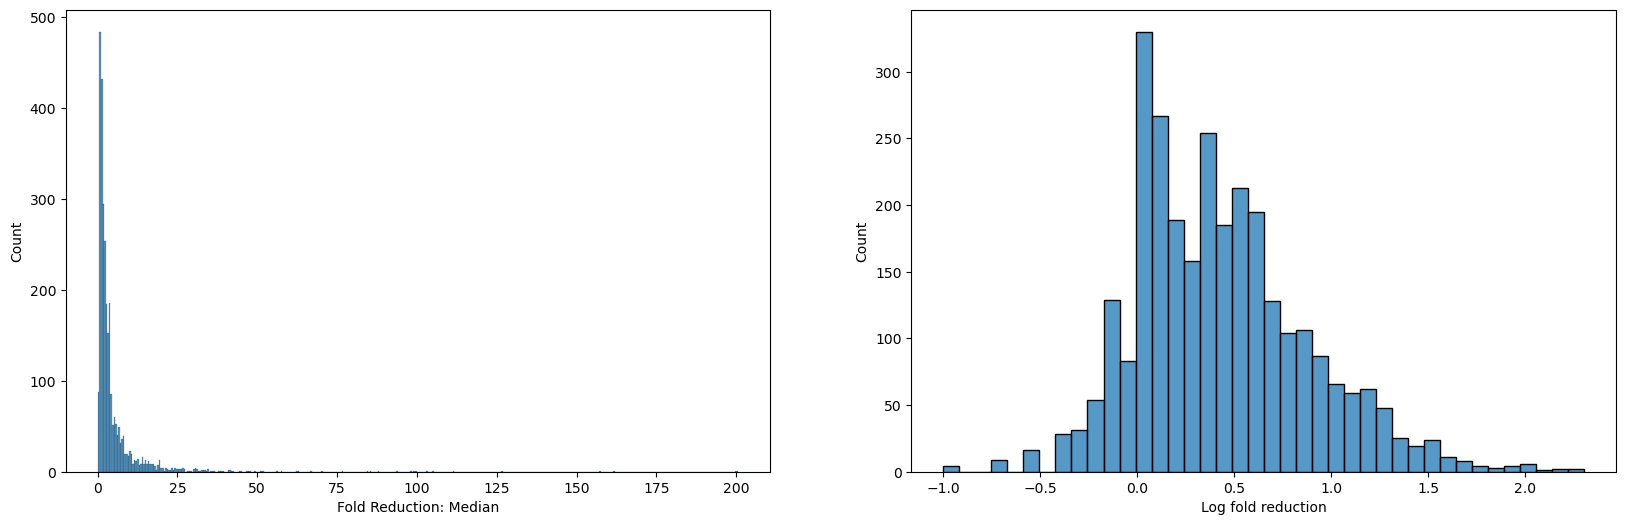

In [275]:
plasma_lite['Log fold reduction'] = np.log10(plasma_lite['Fold Reduction: Median'])

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
sns.histplot(x='Fold Reduction: Median',
             data=plasma_lite,
             ax=axes[0])
sns.histplot(x='Log fold reduction',
             data=plasma_lite,
             ax=axes[1])